# 02 — Exploratory Analysis & Preprocessing

Second notebook in the pipeline (see `01_data_preparation.ipynb` for the full layout). Loads the
manifest produced by notebook 01 rather than re-downloading or re-splitting anything.

This notebook covers:
- **Step 2 — Exploratory Analysis**: sample visualization, pixel/size/coverage distributions, data
  integrity checks (corrupt files, duplicates, mask misalignment)
- **Step 3 — Preprocessing**: resize/pad, intensity normalization, CLAHE, denoising *(added after
  Step 2 is reviewed)*

## Step 2 — Exploratory Analysis

### 2.0 Load manifest

Descriptive plots (intensity, size, coverage histograms) use the **train split only** — standard
practice to avoid letting val/test data quietly influence preprocessing choices made later in this
notebook. Data-integrity checks (corrupt files, duplicates, mask misalignment) run over the **full
labeled set** (all splits), since those are dataset-quality issues, not modeling decisions.

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

DATA_DIR = Path("../data")
assert (DATA_DIR / "manifest.csv").exists(), "Run 01_data_preparation.ipynb first to generate data/manifest.csv"

manifest = pd.read_csv(DATA_DIR / "manifest.csv")
stats_df = pd.read_csv(DATA_DIR / "manifest_stats.csv")
manifest = manifest.merge(stats_df[["id", "width", "height", "mode", "lung_pixel_ratio"]], on="id")

_HOME = str(Path.home())
def anon(path) -> str:
    # mask the local home directory before printing/displaying (notebook is shared publicly)
    return str(path).replace(_HOME, "<USER>")

RNG = np.random.default_rng(42)
print(f"Loaded {len(manifest)} labeled pairs")
manifest[["id", "source", "split", "width", "height", "mode", "lung_pixel_ratio"]].head()

Loaded 704 labeled pairs


,id,source,split,width,height,mode,lung_pixel_ratio
0,CHNCXR_0001_0,Shenzhen,train,3000,2919,P,0.245491
1,CHNCXR_0002_0,Shenzhen,test,3000,2951,P,0.216718
2,CHNCXR_0003_0,Shenzhen,train,2987,2945,P,0.239267
3,CHNCXR_0004_0,Shenzhen,train,3000,2933,P,0.222923
4,CHNCXR_0005_0,Shenzhen,test,3000,2933,P,0.238209


### 2.1 Sample image / mask pairs

A grid of representative train-split examples from each source: original image, ground-truth mask,
and an overlay of the two.

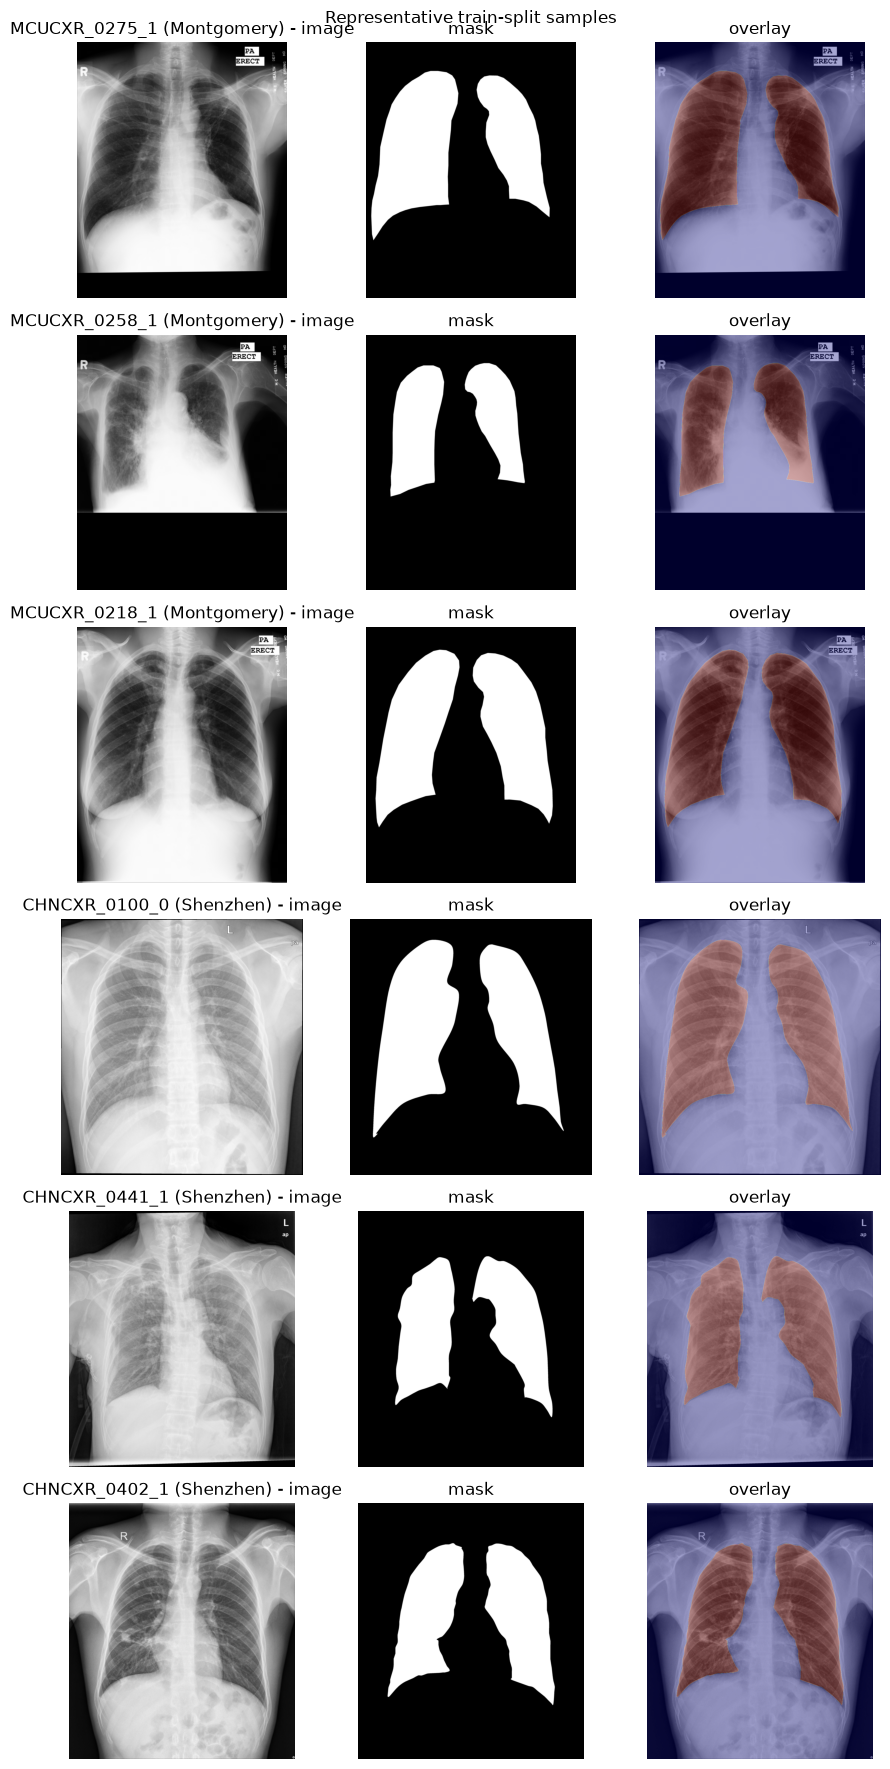

In [2]:
def load_gray(path, max_size=1024):
    # downsample for display speed only -- some source images are ~20 megapixels
    im = Image.open(path).convert("L")
    im.thumbnail((max_size, max_size))
    return np.array(im)

def show_pairs(df, title):
    fig, axes = plt.subplots(len(df), 3, figsize=(9, 3 * len(df)))
    if len(df) == 1:
        axes = axes[None, :]
    for row, r in zip(axes, df.itertuples()):
        img = load_gray(r.image_path)
        mask = load_gray(r.mask_path)
        row[0].imshow(img, cmap="gray"); row[0].set_title(f"{r.id} ({r.source}) - image"); row[0].axis("off")
        row[1].imshow(mask, cmap="gray"); row[1].set_title("mask"); row[1].axis("off")
        row[2].imshow(img, cmap="gray"); row[2].imshow(mask, cmap="jet", alpha=0.35); row[2].set_title("overlay"); row[2].axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

train_df = manifest[manifest.split == "train"]
sample_ids = pd.concat([
    train_df[train_df.source == "Montgomery"].sample(3, random_state=42),
    train_df[train_df.source == "Shenzhen"].sample(3, random_state=42),
])
show_pairs(sample_ids, "Representative train-split samples")

### 2.2 Pixel intensity histograms

Grayscale intensity distribution by source (train split). Images are downsampled to at most
512px on the long side before histogramming purely for speed — this does not meaningfully change
the shape of an intensity distribution.

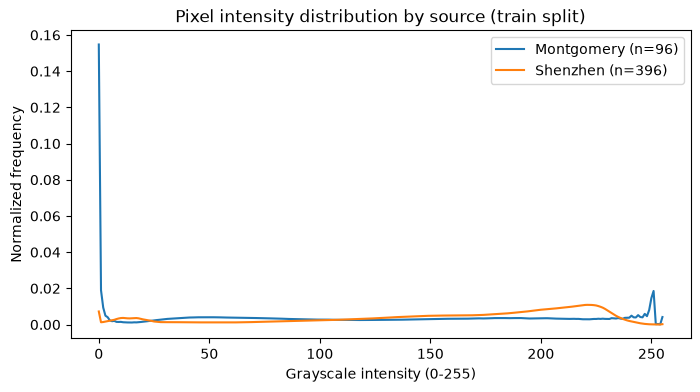

In [3]:
def gray_histogram(path, max_size=512):
    im = Image.open(path).convert("L")
    im.thumbnail((max_size, max_size))
    return np.array(im.histogram(), dtype=np.float64)

plt.figure(figsize=(8, 4))
for src in ["Montgomery", "Shenzhen"]:
    paths = train_df.loc[train_df.source == src, "image_path"]
    agg = np.zeros(256)
    for p in paths:
        agg += gray_histogram(p)
    agg /= agg.sum()
    plt.plot(range(256), agg, label=f"{src} (n={len(paths)})")
plt.xlabel("Grayscale intensity (0-255)")
plt.ylabel("Normalized frequency")
plt.title("Pixel intensity distribution by source (train split)")
plt.legend()
plt.show()

### 2.3 Image size distribution

Width vs. height per source (train split) — confirms the two sources occupy very different,
non-overlapping resolution ranges, which Step 3 must normalize away.

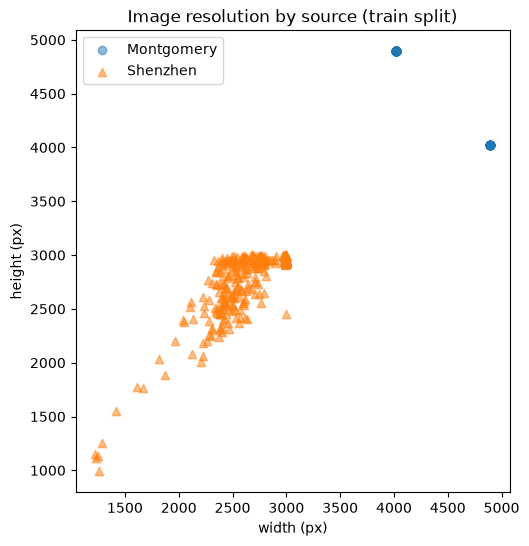

In [4]:
plt.figure(figsize=(6, 6))
for src, marker in [("Montgomery", "o"), ("Shenzhen", "^")]:
    sub = train_df[train_df.source == src]
    plt.scatter(sub.width, sub.height, label=src, alpha=0.5, marker=marker)
plt.xlabel("width (px)")
plt.ylabel("height (px)")
plt.title("Image resolution by source (train split)")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

### 2.4 Mask coverage ratio histogram

Distribution of the lung/background pixel ratio (computed in notebook 01) per source.

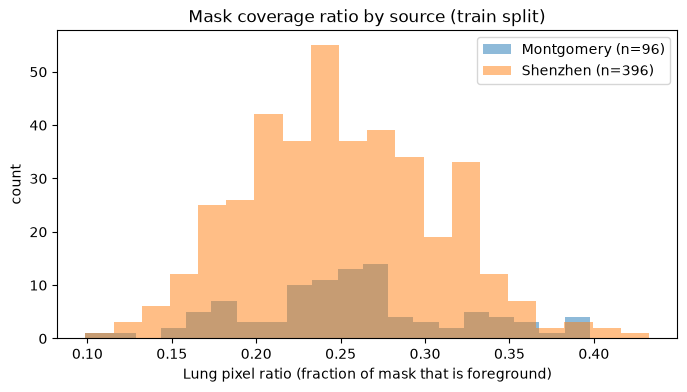

In [5]:
plt.figure(figsize=(8, 4))
for src in ["Montgomery", "Shenzhen"]:
    sub = train_df.loc[train_df.source == src, "lung_pixel_ratio"]
    plt.hist(sub, bins=20, alpha=0.5, label=f"{src} (n={len(sub)})")
plt.xlabel("Lung pixel ratio (fraction of mask that is foreground)")
plt.ylabel("count")
plt.title("Mask coverage ratio by source (train split)")
plt.legend()
plt.show()

### 2.5 Data integrity: corrupt files

Every image and mask file in the labeled manifest (all splits) is opened and verified.

In [6]:
def check_readable(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True, None
    except (UnidentifiedImageError, OSError) as e:
        return False, str(e)

corrupt = []
for r in manifest.itertuples():
    ok, err = check_readable(r.image_path)
    if not ok:
        corrupt.append(("image", r.id, err))
    ok, err = check_readable(r.mask_path)
    if not ok:
        corrupt.append(("mask", r.id, err))

print(f"Corrupt/unreadable files out of {2*len(manifest)} checked: {len(corrupt)}")
for kind, id_, err in corrupt[:10]:
    print(f"  {kind} {id_}: {err}")

Corrupt/unreadable files out of 1408 checked: 0


### 2.6 Data integrity: duplicate images

Exact-duplicate detection via MD5 hash of raw file bytes (cheap, no decoding) across all labeled
images.

In [7]:
def md5_of_file(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

manifest["image_md5"] = [md5_of_file(p) for p in manifest["image_path"]]
dup_counts = manifest["image_md5"].value_counts()
dupes = dup_counts[dup_counts > 1]
n_extra_copies = int(dupes.sum() - len(dupes)) if len(dupes) else 0
print(f"Duplicate groups: {len(dupes)}  (extra copies beyond first occurrence: {n_extra_copies})")
if len(dupes):
    display(manifest[manifest.image_md5.isin(dupes.index)][["id", "source", "split", "image_md5"]].sort_values("image_md5"))

Duplicate groups: 0  (extra copies beyond first occurrence: 0)


### 2.7 Data integrity: mask misalignment

No ground-truth-free way to prove alignment exactly, so we combine a statistical outlier flag
(lung coverage ratio far outside the typical IQR range — a strong signal of an empty, inverted, or
badly misaligned mask) with a visual spot-check of the flagged cases.

Lung-coverage outliers outside IQR fence [0.094, 0.410]: 2 / 704


,id,source,split,lung_pixel_ratio
386,CHNCXR_0455_1,Shenzhen,val,0.083505
290,CHNCXR_0339_1,Shenzhen,train,0.432649


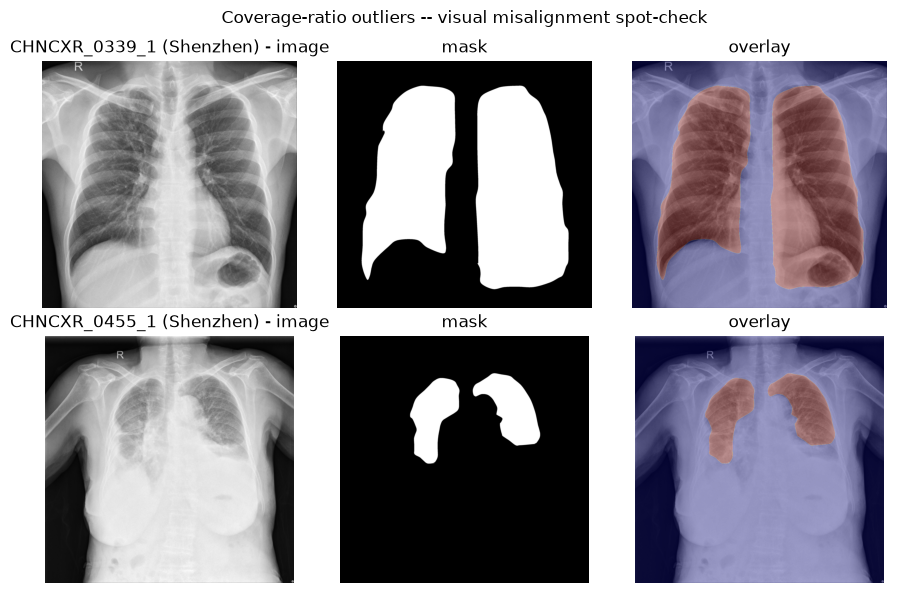

In [8]:
q1, q3 = manifest["lung_pixel_ratio"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = manifest[(manifest.lung_pixel_ratio < lo) | (manifest.lung_pixel_ratio > hi)]
print(f"Lung-coverage outliers outside IQR fence [{lo:.3f}, {hi:.3f}]: {len(outliers)} / {len(manifest)}")
if len(outliers):
    display(outliers[["id", "source", "split", "lung_pixel_ratio"]].sort_values("lung_pixel_ratio"))
    show_pairs(outliers.head(4), "Coverage-ratio outliers -- visual misalignment spot-check")
else:
    print("No coverage-ratio outliers found; no evidence of gross mask misalignment.")

## Step 3 — Image Preprocessing

Pipeline, applied in this order (chosen for correctness, not the order the steps are listed in the
assignment): **resize/pad → denoise → CLAHE → normalize**. Denoising has to happen *before* CLAHE,
because CLAHE is a local-contrast operation and will aggressively amplify whatever high-frequency
noise is still present if applied first. Normalization is the last step since it's just a final
rescale of whatever intensities come out of the earlier stages.

Every step is applied identically to the image and to its mask where relevant (same geometric
transform, different interpolation — nearest-neighbor for the mask to keep it binary), so the two
stay pixel-aligned throughout.

In [9]:
import cv2

TARGET_SIZE = 512  # long side after resize; short side is zero-padded to this size too

demo_ids = sample_ids.set_index("id")  # reuse the 3 Montgomery + 3 Shenzhen samples from Step 2
demo_row_mont = demo_ids[demo_ids.source == "Montgomery"].iloc[0]
demo_row_shen = demo_ids[demo_ids.source == "Shenzhen"].iloc[0]
print("Demo samples:", demo_row_mont.name, demo_row_shen.name)

Demo samples: MCUCXR_0275_1 CHNCXR_0100_0


### 3.1 Resize / pad to a consistent shape

Sources span ~1000px to ~4900px per side (Step 2.3), and a plain resize-to-square would stretch
lungs into different aspect ratios for Montgomery vs Shenzhen. Instead we **letterbox**: scale the
longer side to `TARGET_SIZE`, then zero-pad the shorter side to make it square. The transform is a
pure function of the original `(width, height)`, so applying it separately to an image and its mask
(which always share the same original size, per Step 1) keeps them aligned automatically.

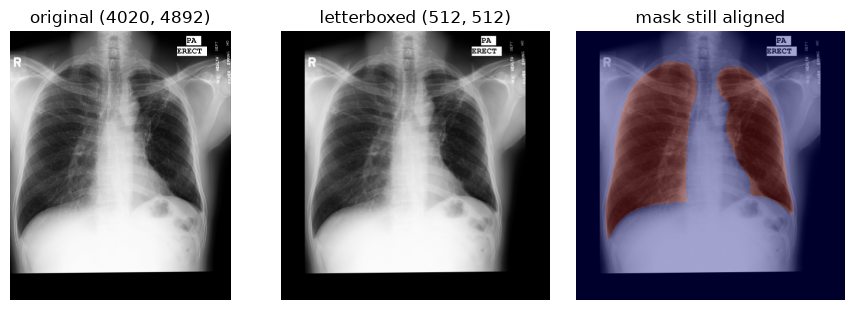

In [10]:
def compute_letterbox(orig_w, orig_h, target=TARGET_SIZE):
    scale = target / max(orig_w, orig_h)
    new_w, new_h = int(round(orig_w * scale)), int(round(orig_h * scale))
    pad_w, pad_h = target - new_w, target - new_h
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2
    return new_w, new_h, top, bottom, left, right

def letterbox_resize(arr, target=TARGET_SIZE, interpolation=cv2.INTER_AREA, pad_value=0):
    h, w = arr.shape[:2]
    new_w, new_h, top, bottom, left, right = compute_letterbox(w, h, target)
    resized = cv2.resize(arr, (new_w, new_h), interpolation=interpolation)
    return cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=pad_value)

def load_array(path):
    return np.array(Image.open(path).convert("L"))

img_raw = load_array(demo_row_mont.image_path)
mask_raw = load_array(demo_row_mont.mask_path)
img_lb = letterbox_resize(img_raw, interpolation=cv2.INTER_AREA)
mask_lb = letterbox_resize(mask_raw, interpolation=cv2.INTER_NEAREST)
mask_lb = (mask_lb > 127).astype(np.uint8) * 255  # re-binarize after interpolation

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
axes[0].imshow(img_raw, cmap="gray"); axes[0].set_title(f"original {img_raw.shape[::-1]}"); axes[0].axis("off")
axes[1].imshow(img_lb, cmap="gray"); axes[1].set_title(f"letterboxed {img_lb.shape[::-1]}"); axes[1].axis("off")
axes[2].imshow(img_lb, cmap="gray"); axes[2].imshow(mask_lb, cmap="jet", alpha=0.35); axes[2].set_title("mask still aligned"); axes[2].axis("off")
fig.tight_layout(); plt.show()

### 3.2 Denoising — kernel choice

X-ray sensor noise (quantum mottle from limited photon counts) is well modeled as approximately
**Gaussian**, not impulsive/salt-and-pepper noise — so a **Gaussian blur** is the better-matched
filter here, and we use it as the pipeline default. A median filter is shown alongside for
comparison: it's the stronger choice when noise is impulsive, but on this kind of sensor noise it
mainly just costs edge sharpness (visible on the rib boundaries below) without removing more noise
than the Gaussian does. Kernel size **5×5**: small enough to preserve fine vascular/rib texture
that matters for lung-boundary segmentation, large enough to visibly suppress pixel-level noise.

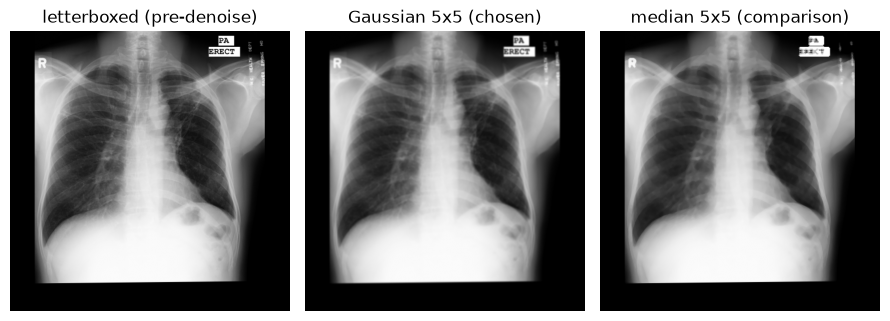

In [11]:
def denoise_gaussian(img, ksize=5):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)

def denoise_median(img, ksize=5):
    return cv2.medianBlur(img, ksize)

gauss = denoise_gaussian(img_lb)
median = denoise_median(img_lb)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, im, title in zip(axes, [img_lb, gauss, median], ["letterboxed (pre-denoise)", "Gaussian 5x5 (chosen)", "median 5x5 (comparison)"]):
    ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
fig.tight_layout(); plt.show()

### 3.3 CLAHE contrast enhancement

Chest X-rays are typically low global contrast with most intensity mass bunched in a narrow band
(visible in the Step 2.2 histograms). Contrast Limited Adaptive Histogram Equalization applies
histogram equalization on local tiles (here 8×8) rather than globally, which brings out local
structure (rib edges, vascular markings) without blowing out already-bright regions the way plain
global histogram equalization would. `clipLimit=2.0` caps how aggressively any single tile's
histogram can be stretched, which is the standard safeguard against over-amplifying noise.

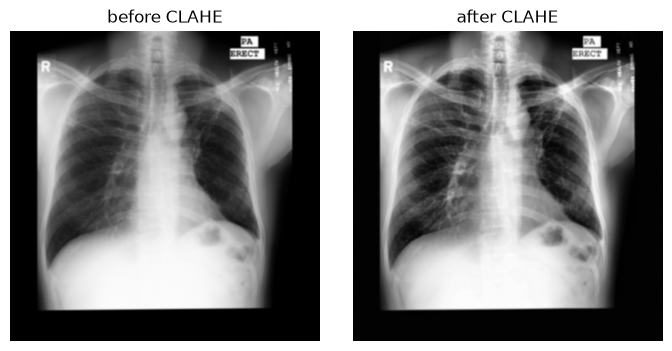

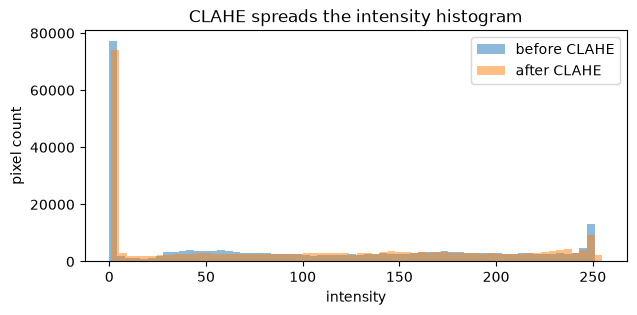

In [12]:
def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(img)

enhanced = apply_clahe(gauss)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(gauss, cmap="gray"); axes[0].set_title("before CLAHE"); axes[0].axis("off")
axes[1].imshow(enhanced, cmap="gray"); axes[1].set_title("after CLAHE"); axes[1].axis("off")
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(gauss.ravel(), bins=64, alpha=0.5, label="before CLAHE")
ax.hist(enhanced.ravel(), bins=64, alpha=0.5, label="after CLAHE")
ax.set_xlabel("intensity"); ax.set_ylabel("pixel count"); ax.legend()
ax.set_title("CLAHE spreads the intensity histogram")
plt.show()

### 3.4 Intensity normalization

Min-max scaling to `[0, 1]` is used as the pipeline default rather than z-score: several of the
classical methods in Step 4 (Otsu, K-means, template matching) work with bounded, non-negative
intensities and are easiest to reason about in a fixed `[0, 1]` (or `[0, 255]`) range, whereas
z-score produces unbounded, mean-centered values (including negatives) that would need extra
handling in those methods. Both are implemented below for completeness.

In [13]:
def normalize_minmax(img):
    img = img.astype(np.float32)
    lo, hi = img.min(), img.max()
    if hi - lo < 1e-6:
        return np.zeros_like(img)
    return (img - lo) / (hi - lo)

def normalize_zscore(img):
    img = img.astype(np.float32)
    mu, sigma = img.mean(), img.std()
    if sigma < 1e-6:
        return np.zeros_like(img)
    return (img - mu) / sigma

mm = normalize_minmax(enhanced)
zs = normalize_zscore(enhanced)
print(f"min-max range: [{mm.min():.3f}, {mm.max():.3f}]   z-score range: [{zs.min():.3f}, {zs.max():.3f}] (mean {zs.mean():.3f}, std {zs.std():.3f})")

min-max range: [0.000, 1.000]   z-score range: [-1.153, 1.749] (mean 0.000, std 1.000)


### 3.5 Full pipeline, end to end

Combines 3.1–3.4 into two functions — `preprocess_image` (letterbox → denoise → CLAHE → normalize)
and `preprocess_mask` (letterbox + re-binarize only, since none of the intensity steps apply to a
mask) — and runs them on both demo samples for a side-by-side sanity check.

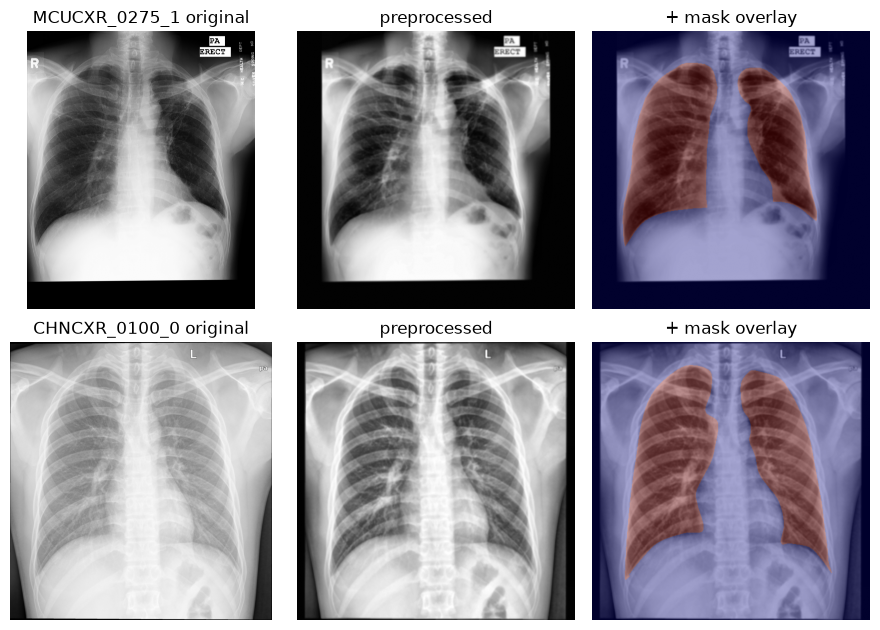

In [14]:
def preprocess_image(path, target_size=TARGET_SIZE, denoise_ksize=5, clahe_clip=2.0, clahe_tile=(8, 8)):
    arr = load_array(path)
    arr = letterbox_resize(arr, target=target_size, interpolation=cv2.INTER_AREA)
    arr = denoise_gaussian(arr, ksize=denoise_ksize)
    arr = apply_clahe(arr, clip_limit=clahe_clip, tile_grid_size=clahe_tile)
    enhanced_uint8 = arr  # 0-255, resized+denoised+contrast-enhanced -- what classical CV methods (Step 4) consume
    normalized_float = normalize_minmax(arr)  # [0,1] float -- equivalent to enhanced_uint8 / 255
    return enhanced_uint8, normalized_float

def preprocess_mask(path, target_size=TARGET_SIZE):
    arr = load_array(path)
    arr = letterbox_resize(arr, target=target_size, interpolation=cv2.INTER_NEAREST)
    return (arr > 127).astype(np.uint8) * 255

fig, axes = plt.subplots(2, 3, figsize=(9, 6.4))
for row, r in zip(axes, [demo_row_mont, demo_row_shen]):
    enh, norm = preprocess_image(r.image_path)
    msk = preprocess_mask(r.mask_path)
    row[0].imshow(load_array(r.image_path), cmap="gray"); row[0].set_title(f"{r.name} original"); row[0].axis("off")
    row[1].imshow(enh, cmap="gray"); row[1].set_title("preprocessed"); row[1].axis("off")
    row[2].imshow(enh, cmap="gray"); row[2].imshow(msk, cmap="jet", alpha=0.35); row[2].set_title("+ mask overlay"); row[2].axis("off")
fig.tight_layout(); plt.show()

### 3.6 Materialize the preprocessed dataset

Running this pipeline is not free (CLAHE + Gaussian blur + decoding ~20-megapixel Montgomery
originals), and every later notebook (03, 04) needs the same preprocessed arrays. So we run it once
here over all 704 labeled pairs and cache the results as PNGs under `data/processed/`, named by
`id` — later notebooks just read `data/processed/images/<id>.png` / `masks/<id>.png` directly
instead of re-running this pipeline.

In [15]:
from tqdm.auto import tqdm

PROC_IMG_DIR = DATA_DIR / "processed" / "images"
PROC_MASK_DIR = DATA_DIR / "processed" / "masks"
PROC_IMG_DIR.mkdir(parents=True, exist_ok=True)
PROC_MASK_DIR.mkdir(parents=True, exist_ok=True)

for r in tqdm(list(manifest.itertuples()), desc="preprocessing"):
    enhanced_uint8, _ = preprocess_image(r.image_path)
    mask_bin = preprocess_mask(r.mask_path)
    Image.fromarray(enhanced_uint8).save(PROC_IMG_DIR / f"{r.id}.png")
    Image.fromarray(mask_bin).save(PROC_MASK_DIR / f"{r.id}.png")

n_imgs = len(list(PROC_IMG_DIR.glob("*.png")))
n_masks = len(list(PROC_MASK_DIR.glob("*.png")))
print(f"Wrote {n_imgs} preprocessed images and {n_masks} masks to data/processed/ (all {TARGET_SIZE}x{TARGET_SIZE})")

# sanity check: shapes and mask binarity on a few random files
for pid in manifest["id"].sample(5, random_state=0):
    im = np.array(Image.open(PROC_IMG_DIR / f"{pid}.png"))
    mk = np.array(Image.open(PROC_MASK_DIR / f"{pid}.png"))
    assert im.shape == (TARGET_SIZE, TARGET_SIZE), f"{pid} image shape {im.shape}"
    assert mk.shape == (TARGET_SIZE, TARGET_SIZE), f"{pid} mask shape {mk.shape}"
    assert set(np.unique(mk).tolist()) <= {0, 255}, f"{pid} mask not binary: {np.unique(mk)}"
print("Sanity check passed: consistent shape and binary masks on sampled files.")

preprocessing:   0%|          | 0/704 [00:00<?, ?it/s]

Wrote 704 preprocessed images and 704 masks to data/processed/ (all 512x512)
Sanity check passed: consistent shape and binary masks on sampled files.
